In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
path = r"https://media.githubusercontent.com/media/shahil04/ds_materials/refs/heads/main/8.0_Machine%20Learning/class/Module%204.2%20insurance_claims_report.csv"
df = pd.read_csv(path)
print(df.head(10))

   months_as_customer  age  policy_number policy_bind_date policy_state  \
0                 328   48         521585       17-10-2014           OH   
1                 228   42         342868       27-06-2006           IN   
2                 134   18         687698       06-09-2000           OH   
3                 256   41         227811       25-05-1990           IL   
4                 228   44         367455       06-06-2014           IL   
5                 256   39         104594       12-10-2006           OH   
6                 137   34         413978       04-06-2000           IN   
7                 165   37         429027       03-02-1990           IL   
8                  27   33         485665       05-02-1997           IL   
9                 212   42         636550       25-07-2011           IL   

  policy_csl  policy_deductable  policy_annual_premium  umbrella_limit  \
0    250/500               1000                1406.91               0   
1    250/500              

In [6]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,17-10-2014,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,27-06-2006,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,18,687698,06-09-2000,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,25-05-1990,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,06-06-2014,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [8]:
df.describe

<bound method NDFrame.describe of      months_as_customer  age  policy_number policy_bind_date policy_state  \
0                   328   48         521585       17-10-2014           OH   
1                   228   42         342868       27-06-2006           IN   
2                   134   18         687698       06-09-2000           OH   
3                   256   41         227811       25-05-1990           IL   
4                   228   44         367455       06-06-2014           IL   
..                  ...  ...            ...              ...          ...   
995                   3   38         941851       16-07-1991           OH   
996                 285   41         186934       05-01-2014           IL   
997                 130   34         918516       17-02-2003           OH   
998                 458   62         533940       18-11-2011           IL   
999                 456   60         556080       11-11-1996           OH   

    policy_csl  policy_deductable  policy

In [9]:
df.shape

(1000, 39)

In [10]:
df.size

39000

In [11]:
df.isnull().sum()

months_as_customer              0
age                             0
policy_number                   0
policy_bind_date                0
policy_state                    0
policy_csl                      0
policy_deductable               0
policy_annual_premium           0
umbrella_limit                  0
insured_zip                     0
insured_sex                     0
insured_education_level         0
insured_occupation              0
insured_hobbies                 0
insured_relationship            0
capital-gains                   0
capital-loss                    0
incident_date                   0
incident_type                   0
collision_type                  0
incident_severity               0
authorities_contacted          91
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
witnesses     

In [12]:
df["authorities_contacted"].mode()

0    Police
Name: authorities_contacted, dtype: object

In [13]:
df["authorities_contacted"].value_counts()

authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
Name: count, dtype: int64

In [14]:
df["authorities_contacted"].fillna(df["authorities_contacted"].mode()[0],inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_8952\2433094147.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["authorities_contacted"].fillna(df["authorities_contacted"].mode()[0],inplace=True)


In [15]:
df.isnull().sum()

months_as_customer             0
age                            0
policy_number                  0
policy_bind_date               0
policy_state                   0
policy_csl                     0
policy_deductable              0
policy_annual_premium          0
umbrella_limit                 0
insured_zip                    0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
insured_relationship           0
capital-gains                  0
capital-loss                   0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
incident_city                  0
incident_location              0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
property_damage                0
bodily_injuries                0
witnesses                      0
police_rep

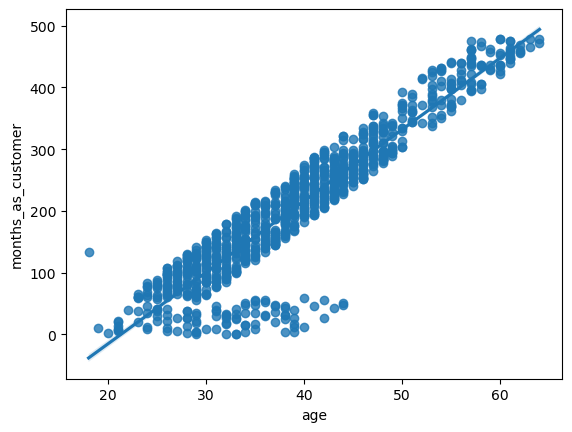

In [16]:
ax=sns.regplot(x='age',y='months_as_customer',data=df)

In [17]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported'],
      dtype='object')

In [18]:
len(df.columns)
df.shape

(1000, 39)

In [19]:
X = df[["months_as_customer","age","policy_annual_premium","auto_year" ,"umbrella_limit"]]

y = df['fraud_reported']

In [20]:
X

,months_as_customer,age,policy_annual_premium,auto_year,umbrella_limit
0,328,48,1406.91,2004,0
1,228,42,1197.22,2007,5000000
2,134,18,1413.14,2007,5000000
3,256,41,1415.74,2014,6000000
4,228,44,1583.91,2009,6000000
...,...,...,...,...,...
995,3,38,1310.80,2006,0
996,285,41,1436.79,2015,0
997,130,34,1383.49,1996,3000000
998,458,62,1356.92,1998,5000000


In [21]:
y

0      Y
1      Y
2      N
3      Y
4      N
      ..
995    N
996    N
997    N
998    N
999    N
Name: fraud_reported, Length: 1000, dtype: object

In [22]:
X.shape

(1000, 5)

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12)

In [25]:
X_train.shape

(700, 5)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [27]:
pipe = make_pipeline(StandardScaler(), LogisticRegression())
pipe.fit(X_train, y_train)  

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [28]:
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score
y_pred = pipe.predict(X_test)

print('Accuracy: {}'.format(accuracy_score(y_test, y_pred)))

Accuracy: 0.7466666666666667


In [29]:
print(confusion_matrix(y_test, y_pred))

[[224   0]
 [ 76   0]]


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           N       0.75      1.00      0.85       224
           Y       0.00      0.00      0.00        76

    accuracy                           0.75       300
   macro avg       0.37      0.50      0.43       300
weighted avg       0.56      0.75      0.64       300



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
import pickle
filename = 'logistic_model.pkl'

pickle.dump(pipe, open(filename, 'wb'))

In [32]:
pipe = make_pipeline(StandardScaler(), LogisticRegression(penalty="l2",solver="liblinear",C=.5))

pipe.fit(X_train, y_train) 

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=0.5, solver='liblinear'))])

In [33]:
import gradio as gr
import pandas as pd
import pickle
with open("logistic_model.pkl", "rb") as f:
    model = pickle.load(f)

numerical_cols_for_prediction = [
    'months_as_customer',
    'age',
    'policy_annual_premium',
    'auto_year',
    'umbrella_limit'
]

def predict_fraud(months_as_customer, age, policy_annual_premium, auto_year, umbrella_limit):
    # Create input DataFrame
    input_data = pd.DataFrame({
        'months_as_customer': [months_as_customer],
        'age': [age],
        'policy_annual_premium': [policy_annual_premium],
        'auto_year': [auto_year],
        'umbrella_limit': [umbrella_limit]
    })
    prediction = model.predict(input_data[numerical_cols_for_prediction])

    if prediction[0] == 'Y':
        return "🚨 Fraud Reported (Y)"
    else:
        return "✅ No Fraud Reported (N)"

interface = gr.Interface(
    fn=predict_fraud,
    inputs=[
        gr.Number(label="Months as Customer", value=100),
        gr.Number(label="Age", value=30),
        gr.Number(label="Policy Annual Premium", value=1000),
        gr.Number(label="Auto Year", value=2010),
        gr.Number(label="Umbrella Limit", value=0)
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="Insurance Claim Fraud Prediction",
    description="Predict whether an insurance claim is fraudulent using a trained Logistic Regression model."
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
